In [1]:
import polars as pl
import os
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report

from statistics import mean

In [2]:
WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/08_HepG2'
DATASET_DIR = '/group/pmc021/amunif/epi-thesis/dataset'
label_column = "value_1"

In [3]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [4]:
# Load the HepG2 data
gene_pl = pl.read_parquet(os.path.join(WORKING_DIR, 'dataset', f'gene_w_label_{label_column}.parquet'))

In [5]:
gene_pl

gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label
str,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,f64,i32
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000006""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0888452,0
"""XLOC_000007""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,4.04743,1
"""XLOC_000008""","[0.0, 0.0, … 0.0]",6,"[0.0, 0.0, … 0.0]",3,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",2,"[0.0, 0.0, … 0.0]",0,26.7934,1
…,…,…,…,…,…,…,…,…,…,…,…,…
"""XLOC_030009""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_030012""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_030014""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0


In [6]:
marker_list = ['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']

In [7]:
gene_features = gene_pl.with_columns(
    pl.struct(marker_list).map_elements(
        lambda x: [x[col_name] for col_name in marker_list],
        return_dtype = pl.List(pl.List(pl.Float64))
    ).alias("histone")
)

In [8]:
gene_features

gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label,histone
str,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,f64,i32,list[list[f64]]
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_000006""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0888452,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_000007""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,4.04743,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_000008""","[0.0, 0.0, … 0.0]",6,"[0.0, 0.0, … 0.0]",3,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",2,"[0.0, 0.0, … 0.0]",0,26.7934,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""XLOC_030009""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_030012""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_030014""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"


In [9]:
# Select X and y column
X = gene_features.select(pl.col('histone')).to_series().to_list()
y = gene_features.select(pl.col('label')).to_series().to_list()

In [10]:
# Convert to Numpy array
X = np.array(X)
y = np.array(y)

In [11]:
# Split the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.666, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [12]:
print("Train set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Train set shape: (7399, 5, 4000) (7399,)
Validation set shape: (7377, 5, 4000) (7377,)
Test set shape: (7378, 5, 4000) (7378,)


In [13]:
# Convert numpy arrays to PyTorch tensors

X_train = torch.from_numpy(X_train).float().unsqueeze(1).to(device)
X_val = torch.from_numpy(X_val).float().unsqueeze(1).to(device)
X_test = torch.from_numpy(X_test).float().unsqueeze(1).to(device)

y_train = torch.from_numpy(y_train).float().to(device)
y_val = torch.from_numpy(y_val).float().to(device)
y_test = torch.from_numpy(y_test).float().to(device)

In [14]:
# Create DataLoaders
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [15]:
# Define DeepClassifer Class
class DeepClassifier(nn.Module):
    def __init__(self, input_dim = [5, 4000], out_channels = 50, conv_kernel_size = 10, max_pooling_kernel_size = 5):
        super(DeepClassifier, self).__init__()
        
        flatten_dim = out_channels * ((input_dim[1] - conv_kernel_size + 1) // max_pooling_kernel_size)

        self.conv = nn.Conv2d(1, out_channels, kernel_size=(input_dim[0], conv_kernel_size))
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d((1, max_pooling_kernel_size))
        self.dropout = nn.Dropout(0.5)
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(flatten_dim, 625)
        self.linear2 = nn.Linear(625, 125)
        self.linear3 = nn.Linear(125, 2)
        self.softmax = nn.LogSoftmax(dim=1)
        

    def forward(self, x):
        # Stage 1: filter bank -> squashing -> max pooling
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)

        # Stage 2: standar 2-layer neural network        
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.relu(x)
        x = self.linear3(x)
        x = self.softmax(x)
        return x

In [16]:
# Initialize the kernel size and pooling size
# kernel_size, pool_size = 5, 2
# kernel_size, pool_size = 5, 5
# kernel_size, pool_size = 10, 2
kernel_size, pool_size = 10, 5

In [19]:
# Define the model instances
model = DeepClassifier(conv_kernel_size = kernel_size, max_pooling_kernel_size = pool_size).to(device)
criterion = nn.NLLLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.SGD(model.parameters(), lr=0.001)
num_epochs = 100

# For tracking train and validation
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []
val_precisions = []
val_recalls = []
val_f1_scores = []

kernel_arr, pool_arr = [], []

# For saving the best model
best_val_metric = float('-inf')
best_model_path = os.path.join(WORKING_DIR, 'model', label_column, f'best_model-{kernel_size}-{pool_size}.pth')

In [20]:
for epoch in range(num_epochs):
    # Training phase
    model.train()  # Set the model to training mode
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    train_true_labels = []
    train_predicted_probs = []
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.cuda(), labels.type(torch.LongTensor).cuda())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        train_true_labels.extend(labels.cpu().numpy())
        train_predicted_probs.extend(predicted.cpu().numpy())
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_auc_score = roc_auc_score(train_true_labels, train_predicted_probs)
    
    train_losses.append(round(avg_train_loss, 4))
    train_accuracies.append(round(train_accuracy, 2))
    train_aucs.append(round(train_auc_score, 2))
    
    # Validation phase
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_metric = 0
    val_true_labels = []
    val_predicted_probs = []
    
    with torch.no_grad():  # Disable gradient computation
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs.cuda(), labels.type(torch.LongTensor).cuda())
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            val_true_labels.extend(labels.cpu().numpy())
            val_predicted_probs.extend(predicted.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total
    val_metric = val_correct / len(val_loader)

    # Calculate precision, recall, and F1-score
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        val_true_labels, 
        val_predicted_probs, 
        average='binary'  # Use macro average for multi-class classification
    )

    # Save the best model
    if val_metric > best_val_metric:
        best_val_metric = val_metric
        torch.save(model.state_dict(), best_model_path)
        print(f"New best model saved with validation metric: {best_val_metric:.4f}")
    
    val_true_labels = np.array(val_true_labels)
    val_predicted_probs = np.array(val_predicted_probs)
    val_auc_score = roc_auc_score(val_true_labels, val_predicted_probs)

    val_losses.append(round(avg_val_loss, 4))
    val_accuracies.append(round(val_accuracy, 2))
    val_aucs.append(round(val_auc_score, 2))
    val_precisions.append(round(precision, 2))
    val_recalls.append(round(recall, 2))
    val_f1_scores.append(round(f1_score, 2))

    kernel_arr.append(kernel_size)
    pool_arr.append(pool_size)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] - '
          f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}% - '
          f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
          f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
          f'AUC: {val_auc_score:.2f}')

print("Training finished!")

New best model saved with validation metric: 15.9654
Epoch [1/100] - [TRAIN] Loss: 0.6868, Accuracy: 50.01% - [VAL] Loss: 0.6753, Accuracy: 49.99%, Precision: 0.50, Recall: 1.00, F1-Score: 0.67, AUC: 0.50
New best model saved with validation metric: 24.2727
Epoch [2/100] - [TRAIN] Loss: 0.6664, Accuracy: 60.04% - [VAL] Loss: 0.6496, Accuracy: 76.01%, Precision: 0.72, Recall: 0.85, F1-Score: 0.78, AUC: 0.76
New best model saved with validation metric: 24.4372
Epoch [3/100] - [TRAIN] Loss: 0.6384, Accuracy: 76.60% - [VAL] Loss: 0.6192, Accuracy: 76.52%, Precision: 0.74, Recall: 0.81, F1-Score: 0.78, AUC: 0.77
New best model saved with validation metric: 24.4848
Epoch [4/100] - [TRAIN] Loss: 0.6073, Accuracy: 77.35% - [VAL] Loss: 0.5898, Accuracy: 76.67%, Precision: 0.75, Recall: 0.80, F1-Score: 0.77, AUC: 0.77
Epoch [5/100] - [TRAIN] Loss: 0.5787, Accuracy: 77.36% - [VAL] Loss: 0.5670, Accuracy: 76.62%, Precision: 0.76, Recall: 0.78, F1-Score: 0.77, AUC: 0.77
Epoch [6/100] - [TRAIN] Loss

In [21]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, kernel_size, pool_size):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 6))
    
    # Plot for training and validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'blue', label='Training Loss')
    plt.plot(epochs, val_losses, 'orange', label='Validation Loss')
    plt.title(f'Training and Validation Loss, kernel_size = {kernel_size}, pool_size = {pool_size}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot for training and validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'blue', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'orange', label='Validation Accuracy')
    plt.title(f'Training and Validation Accuracy, kernel_size = {kernel_size}, pool_size = {pool_size}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()

    img_name = '-'.join(marker_list) + f"-{kernel_size}-{pool_size}.png"
    plt.savefig(os.path.join(WORKING_DIR, 'output', label_column, 'fig', 'train', img_name))
    
    plt.show()

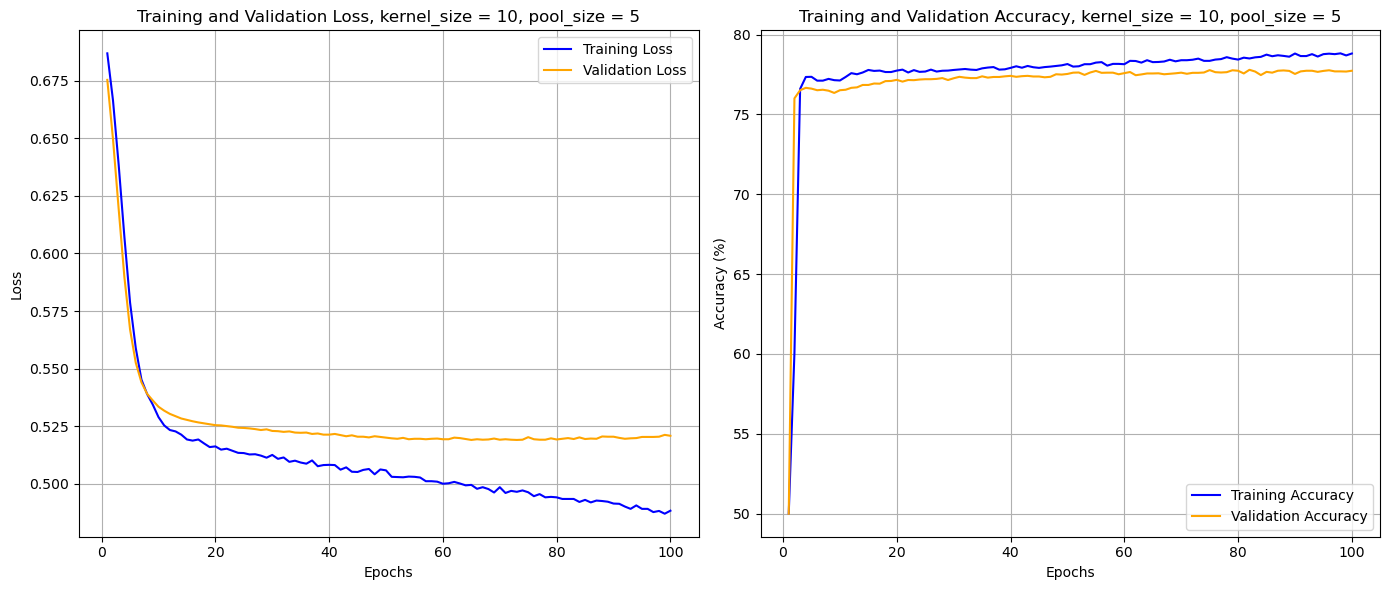

In [22]:
plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, kernel_size, pool_size)

In [23]:
# Load the best model
best_model = DeepClassifier(conv_kernel_size = kernel_size, max_pooling_kernel_size = pool_size).to(device)
best_model.load_state_dict(torch.load(best_model_path))
best_model.eval()

# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = best_model(inputs)
        # probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        test_predictions.extend(predicted.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())

# Calculate evaluation metric
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='binary'  # Use 'macro' for multi-class
)
test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
print(f"Accuracy Score on test set: {test_acc_score:.2f} %")
test_auc_score = roc_auc_score(test_true_labels, test_predictions)
print(f"AUC Score on test set: {test_auc_score:.2f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(test_true_labels, test_predictions))

# Confusion Matrix
conf_matrix = confusion_matrix(test_true_labels, test_predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy Score on test set: 76.86 %
AUC Score on test set: 0.77
Precision: 0.7470
Recall: 0.8124
F1-Score: 0.7783

Detailed Classification Report:
              precision    recall  f1-score   support

         0.0       0.79      0.72      0.76      3689
         1.0       0.75      0.81      0.78      3689

    accuracy                           0.77      7378
   macro avg       0.77      0.77      0.77      7378
weighted avg       0.77      0.77      0.77      7378


Confusion Matrix:
[[2674 1015]
 [ 692 2997]]


In [ ]:
# Setup the output log
file_name = '-'.join(marker_list) + f"-{kernel_size}-{pool_size}.csv"
result_file = os.path.join(WORKING_DIR, 'output', label_column, 'train', f"{file_name}")

experiment_results = {
    'kernel_size'   : kernel_arr,
    'pool_size'     : pool_arr,
    'train_loss'    : train_losses,
    'train_accuracy': train_accuracies,
    'train_auc'     : train_aucs,
    'val_loss'      : val_losses,
    'val_accuracy'  : val_accuracies,
    'val_auc'       : val_aucs
}

experiment_pl = pl.DataFrame(experiment_results)

experiment_pl.write_csv(result_file)

In [ ]:
# Test output
test_name = '-'.join(marker_list) + f"-{kernel_size}-{pool_size}.csv"
test_file = os.path.join(WORKING_DIR, 'output', label_column, 'test',f"{test_name}")

test_results = {
    'kernel_size' : kernel_size,
    'pool_size'   : pool_size,
    'test_acc'    : round(test_acc_score, 4),
    'test_auc'    : round(test_auc_score, 4)
}

test_pl = pl.DataFrame(test_results)
test_pl.write_csv(test_file)

In [ ]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_true_labels, test_predictions) 
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC for HepG2 Classification, kernel_size = {kernel_size}, pool_size = {pool_size}')
plt.legend()

img_name = '-'.join(marker_list) + f"-{kernel_size}-{pool_size}.png"
plt.savefig(os.path.join(WORKING_DIR, 'output', label_column, 'fig', 'roc', img_name))

plt.show()